### Determining the relation between *semi-major axis* and the FWHM of the spectra profiles

In [1]:
!hostname

mtx37


In [2]:
import numpy as np
from matplotlib import pyplot as plt

from astropy.table import Table

import gelsa
from gelsa import galaxy
from gelsa.sgs import datastore
from gelsa import visu

import tqdm

In [3]:
from profile_fitter import Profile_Fitter

In [4]:
from gelsa.sgs import datastore

Next we set the IDs of the considered pointings (0, -4, +4 tilt). We selected these randomly in the "**simulation_full_dataset.ipynb**" code

In [5]:
pt_ind = [30477, 30444, 30399] 

#### Now we load the EDFN_deep.fits data

In [6]:
cat = Table.read("/scratch/astro/nicolo.fiaba/EDFN_deep.fits")
print(len(cat))
magh = -2.5*np.log10(cat['FLUX_H_TEMPLFIT_MWCORR']/1e6) + 8.9

print(np.percentile(magh, (10,50,90)))

sel = (cat['SEMIMAJOR_AXIS'] < 200) & (magh < 20)

cat = cat[sel]
print(len(cat))

2749693
FLUX_H_TEMPLFIT_MWCORR
----------------------
      19.5453844638554
    22.260002932684408
    23.286753307530915


/home/PERSONALE/nicolo.fiaba/miniconda3/envs/myenv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:4842: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedColumn.
  arr.partition(


363627


In [8]:
smj_centers = [5, 15, 20, 25, 30, 35, 45, 50]
PF = Profile_Fitter(pt_ind, cat)
m_fit, q_fit, fwhm, avg_spectra = PF.fit_single_detector(det_n=0, smjax_centers=smj_centers, pt_id=pt_ind[1], num_per_range=3)

got username `nfiaba` and password ***
DpdSirScienceFrame {'ppo_id': None, 'subsample_name': None, 'tile_index': None, 'pointing_id': 30444, 'detector_id': None, 'filter': None, 'plan_id': None, 'fields': None}
key='pointing_id_30444'
> Query: DataSetRelease='DR1_R1' CatalogOrigin=None product='DpdSirScienceFrame'
Header.DataSetRelease=DR1_R1&Data.ObservationSequence.PointingId=30444
Query submitted at 2025-10-16 10:45:18.566216


ConnectionResetError: 

In [11]:
fit_coeffs, _ = PF.fit_full_frame(smjax_centers=smj_centers, pt_id=pt_ind[2], num_per_range=3)

got username `` and password ***
DpdSirScienceFrame {'ppo_id': None, 'subsample_name': None, 'tile_index': None, 'pointing_id': 30399, 'detector_id': None, 'filter': None, 'plan_id': None, 'fields': None}
key='pointing_id_30399'
got len(path_hits)=2
loading /scratch/astro/nicolo.fiaba/gelsa-spectra/calib/SIR_Calib_Opt_EUCLID_2.0.1-CALIBRATION-pcasenov-PLAN-000000-MT0S7VWE-20250123-180643-0-new_opt_cal-0.xml
loading /scratch/astro/nicolo.fiaba/gelsa-spectra/calib/EUC_SIR_DETMODEL_REAL_DATA_OP_02.csv
loading /scratch/astro/nicolo.fiaba/gelsa-spectra/calib/SIR_Calib_Ids_EUCLID_2.0.1-CALIBRATION-pcasenov-PLAN-000001-GQLJE83P-20250211-181132-0-new_ids_calib-0.xml
loading /scratch/astro/nicolo.fiaba/gelsa-spectra/calib/SIR_Calib_Crv_EUCLID_2.0.1-CALIBRATION-pcasenov-PLAN-000001-6NJP8VE4-20250211-163247-0-new_crv_cal-0.xml

Currently fitting for detector 0 in pointing n° 30399
Values in all 3 smjax ranges: set()
Values in exactly 2 smjax ranges: {np.int64(181), np.int64(219), np.int64(189)}


100%|██████████| 3/3 [00:02<00:00,  1.28it/s]


got username `` and password ***
DpdSirScienceFrame {'ppo_id': None, 'subsample_name': None, 'tile_index': None, 'pointing_id': 30399, 'detector_id': None, 'filter': None, 'plan_id': None, 'fields': None}
key='pointing_id_30399'
got len(path_hits)=2
loading /scratch/astro/nicolo.fiaba/gelsa-spectra/calib/SIR_Calib_Opt_EUCLID_2.0.1-CALIBRATION-pcasenov-PLAN-000000-MT0S7VWE-20250123-180643-0-new_opt_cal-0.xml
loading /scratch/astro/nicolo.fiaba/gelsa-spectra/calib/EUC_SIR_DETMODEL_REAL_DATA_OP_02.csv
loading /scratch/astro/nicolo.fiaba/gelsa-spectra/calib/SIR_Calib_Ids_EUCLID_2.0.1-CALIBRATION-pcasenov-PLAN-000001-GQLJE83P-20250211-181132-0-new_ids_calib-0.xml
loading /scratch/astro/nicolo.fiaba/gelsa-spectra/calib/SIR_Calib_Crv_EUCLID_2.0.1-CALIBRATION-pcasenov-PLAN-000001-6NJP8VE4-20250211-163247-0-new_crv_cal-0.xml

Currently fitting for detector 1 in pointing n° 30399
Values in all 3 smjax ranges: set()
Values in exactly 2 smjax ranges: {np.int64(133), np.int64(120), np.int64(158), n

100%|██████████| 3/3 [00:02<00:00,  1.30it/s]


got username `` and password ***
DpdSirScienceFrame {'ppo_id': None, 'subsample_name': None, 'tile_index': None, 'pointing_id': 30399, 'detector_id': None, 'filter': None, 'plan_id': None, 'fields': None}
key='pointing_id_30399'
got len(path_hits)=2
loading /scratch/astro/nicolo.fiaba/gelsa-spectra/calib/SIR_Calib_Opt_EUCLID_2.0.1-CALIBRATION-pcasenov-PLAN-000000-MT0S7VWE-20250123-180643-0-new_opt_cal-0.xml
loading /scratch/astro/nicolo.fiaba/gelsa-spectra/calib/EUC_SIR_DETMODEL_REAL_DATA_OP_02.csv
loading /scratch/astro/nicolo.fiaba/gelsa-spectra/calib/SIR_Calib_Ids_EUCLID_2.0.1-CALIBRATION-pcasenov-PLAN-000001-GQLJE83P-20250211-181132-0-new_ids_calib-0.xml
loading /scratch/astro/nicolo.fiaba/gelsa-spectra/calib/SIR_Calib_Crv_EUCLID_2.0.1-CALIBRATION-pcasenov-PLAN-000001-6NJP8VE4-20250211-163247-0-new_crv_cal-0.xml

Currently fitting for detector 2 in pointing n° 30399
Values in all 3 smjax ranges: set()
Values in exactly 2 smjax ranges: {np.int64(65), np.int64(84), np.int64(11)}


...

100%|██████████| 3/3 [00:02<00:00,  1.26it/s]


got username `` and password ***
DpdSirScienceFrame {'ppo_id': None, 'subsample_name': None, 'tile_index': None, 'pointing_id': 30399, 'detector_id': None, 'filter': None, 'plan_id': None, 'fields': None}
key='pointing_id_30399'
got len(path_hits)=2
loading /scratch/astro/nicolo.fiaba/gelsa-spectra/calib/SIR_Calib_Opt_EUCLID_2.0.1-CALIBRATION-pcasenov-PLAN-000000-MT0S7VWE-20250123-180643-0-new_opt_cal-0.xml
loading /scratch/astro/nicolo.fiaba/gelsa-spectra/calib/EUC_SIR_DETMODEL_REAL_DATA_OP_02.csv
loading /scratch/astro/nicolo.fiaba/gelsa-spectra/calib/SIR_Calib_Ids_EUCLID_2.0.1-CALIBRATION-pcasenov-PLAN-000001-GQLJE83P-20250211-181132-0-new_ids_calib-0.xml
loading /scratch/astro/nicolo.fiaba/gelsa-spectra/calib/SIR_Calib_Crv_EUCLID_2.0.1-CALIBRATION-pcasenov-PLAN-000001-6NJP8VE4-20250211-163247-0-new_crv_cal-0.xml

Currently fitting for detector 14 in pointing n° 30399
Values in all 3 smjax ranges: set()
Values in exactly 2 smjax ranges: {np.int64(177), np.int64(4), np.int64(168), np

100%|██████████| 3/3 [00:02<00:00,  1.29it/s]


got username `` and password ***
DpdSirScienceFrame {'ppo_id': None, 'subsample_name': None, 'tile_index': None, 'pointing_id': 30399, 'detector_id': None, 'filter': None, 'plan_id': None, 'fields': None}
key='pointing_id_30399'
got len(path_hits)=2
loading /scratch/astro/nicolo.fiaba/gelsa-spectra/calib/SIR_Calib_Opt_EUCLID_2.0.1-CALIBRATION-pcasenov-PLAN-000000-MT0S7VWE-20250123-180643-0-new_opt_cal-0.xml
loading /scratch/astro/nicolo.fiaba/gelsa-spectra/calib/EUC_SIR_DETMODEL_REAL_DATA_OP_02.csv
loading /scratch/astro/nicolo.fiaba/gelsa-spectra/calib/SIR_Calib_Ids_EUCLID_2.0.1-CALIBRATION-pcasenov-PLAN-000001-GQLJE83P-20250211-181132-0-new_ids_calib-0.xml
loading /scratch/astro/nicolo.fiaba/gelsa-spectra/calib/SIR_Calib_Crv_EUCLID_2.0.1-CALIBRATION-pcasenov-PLAN-000001-6NJP8VE4-20250211-163247-0-new_crv_cal-0.xml

Currently fitting for detector 15 in pointing n° 30399
Values in all 3 smjax ranges: set()
Values in exactly 2 smjax ranges: {np.int64(135), np.int64(9), np.int64(234), np

100%|██████████| 3/3 [00:02<00:00,  1.32it/s]


In [12]:
print(fit_coeffs)

[[ 4.95283626e-02  1.03571173e+00]
 [ 3.87145907e-02  1.26452079e+00]
 [ 8.36974461e-02  8.56456951e-01]
 [-2.61290987e-03  2.14261997e+00]
 [ 1.29294862e-02  2.53997681e+00]
 [ 3.25672408e-02  1.69116050e+00]
 [-1.00236063e-02  2.33530707e+00]
 [ 8.92626396e-04  2.39561176e+00]
 [ 3.93430585e-03  2.08413363e+00]
 [ 8.77991539e-03  1.98691239e+00]
 [ 7.24400857e-03  1.94412544e+00]
 [-1.04595219e-02  1.91729063e+00]
 [-9.15935108e-03  2.11327735e+00]
 [ 1.20898726e-02  1.96729104e+00]
 [ 1.19255030e-02  1.81992447e+00]
 [-1.50618244e-04  2.03141569e+00]]


In [28]:
fit_line = lambda x: m_fit*x + q_fit
x_val = np.linspace(0, 60, 100)

y_val = fit_line(x_val)

Text(0, 0.5, 'FWHM')

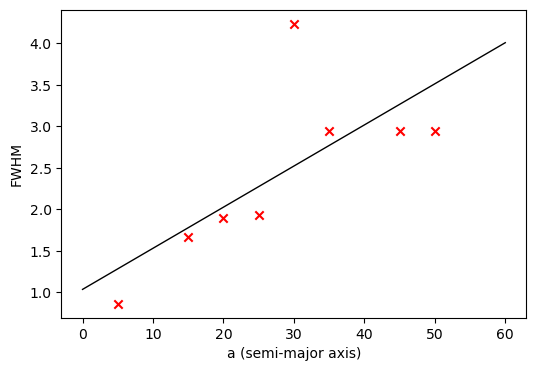

In [29]:
fig = plt.figure(figsize=(6,4))

plt.scatter(smj_centers, fwhm, marker='x', c='r')
plt.plot(x_val, y_val, lw=1, c='k')
plt.xlabel("a (semi-major axis)")
plt.ylabel("FWHM")

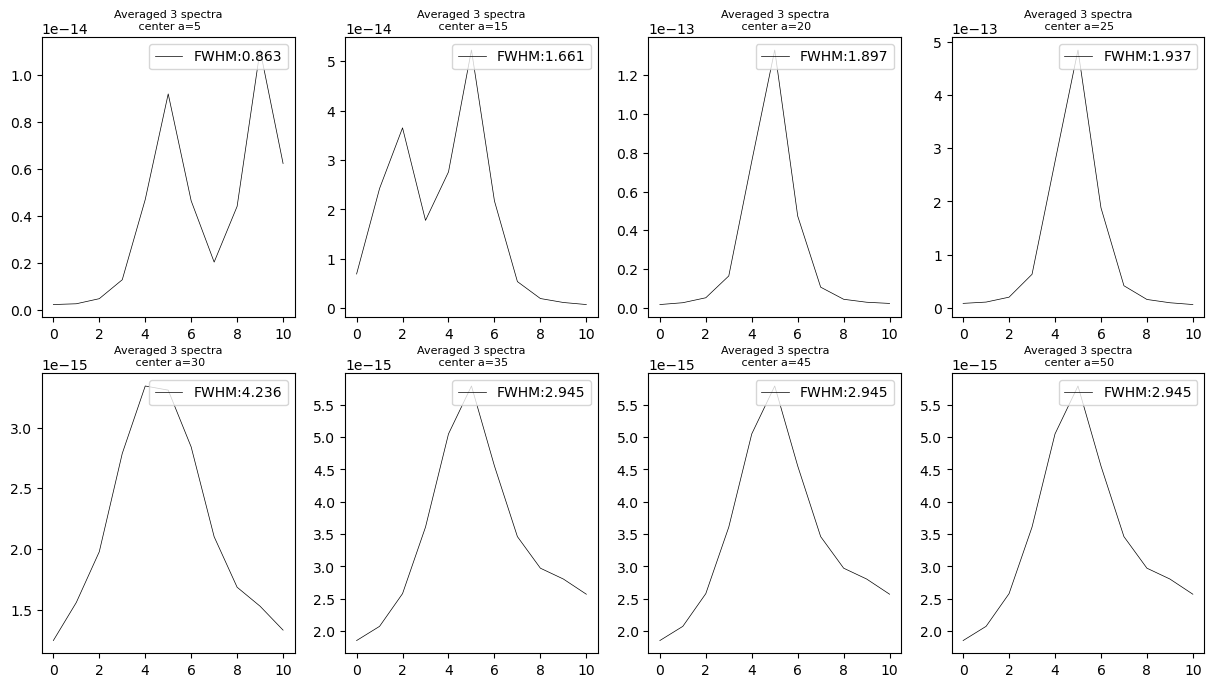

In [30]:
fig, axs = plt.subplots(2, 4, figsize=(15, 8))

for i, ax in enumerate(axs.flat):
    ax.plot(avg_spectra[i], c='k', lw=0.5, label = "FWHM:{}".format(round(fwhm[i], 3)))
    ax.set_title("Averaged 3 spectra\n center a={}".format(smj_centers[i]), fontsize=8)
    ax.legend(loc='upper right')

#### Now we want to simulate the detector using the law we retrieved

In [31]:
from astropy.io import fits
from astropy.constants import c
import astropy.units as u
import astropy.coordinates as coord

Import the real data

In [34]:
DS = datastore.DataStore(username='', password='',
                        cachedir='/scratch/astro/benjamin.granett/datastore'
                        )
file_list = DS.load_sir_pack("DR1_R1", pointing_id_list=[pt_ind[2]])

# Create a Gelsa object
G = gelsa.Gelsa(config_file="/scratch/astro/nicolo.fiaba/gelsa-spectra/calib/gelsa_config.json", 
                calibdir="/scratch/astro/nicolo.fiaba/gelsa-spectra/calib/", zero_order_catalog=None)

# Define the frame for the REAL DATA of the pointing
frame_1 = G.load_spec_frame(**file_list[0])

got username `` and password ***
DpdSirScienceFrame {'ppo_id': None, 'subsample_name': None, 'tile_index': None, 'pointing_id': 30399, 'detector_id': None, 'filter': None, 'plan_id': None, 'fields': None}
key='pointing_id_30399'
got len(path_hits)=2
loading /scratch/astro/nicolo.fiaba/gelsa-spectra/calib/SIR_Calib_Opt_EUCLID_2.0.1-CALIBRATION-pcasenov-PLAN-000000-MT0S7VWE-20250123-180643-0-new_opt_cal-0.xml
loading /scratch/astro/nicolo.fiaba/gelsa-spectra/calib/EUC_SIR_DETMODEL_REAL_DATA_OP_02.csv
loading /scratch/astro/nicolo.fiaba/gelsa-spectra/calib/SIR_Calib_Ids_EUCLID_2.0.1-CALIBRATION-pcasenov-PLAN-000001-GQLJE83P-20250211-181132-0-new_ids_calib-0.xml
loading /scratch/astro/nicolo.fiaba/gelsa-spectra/calib/SIR_Calib_Crv_EUCLID_2.0.1-CALIBRATION-pcasenov-PLAN-000001-6NJP8VE4-20250211-163247-0-new_crv_cal-0.xml


In [35]:
c_cgs = c.cgs.value

# I compute the conversion factor c/lambda^2
factor = lambda lam: (c_cgs*1e8)/(lam**2)

# Center wavelength values in angstrom
j_center =  13673
h_center = 17714

continuum_wavelength = np.linspace(12000, 19000, 100)

In [36]:
# first, I convert the fluxes to erg s^-1 cm^-2 Hz^-1
flux_y_nu = 1e-29*cat["FLUX_Y_TEMPLFIT_MWCORR"]
flux_j_nu = 1e-29*cat["FLUX_J_TEMPLFIT_MWCORR"]
flux_h_nu = 1e-29*cat["FLUX_H_TEMPLFIT_MWCORR"]
    
flux_j_lam = flux_j_nu * factor(j_center)
flux_h_lam = flux_h_nu * factor(h_center)

log_j_flux = np.log10(flux_j_lam)
log_h_flux = np.log10(flux_h_lam)

axis_ratio = 1 - cat['ELLIPTICITY']

# convert the kron radius (in pixel) to a diameter (in arcsec: * 0.1)
fit_line = lambda x: m_fit*x + q_fit
fwhm_arcsec = fit_line(cat["SEMIMAJOR_AXIS"]) * 0.1

In [37]:
cat["AXIS_RATIO"] = axis_ratio
cat["FWHM_ARCSEC"] = fwhm_arcsec

In [38]:
len(cat)

363627

In [39]:
# We do a linear fit to get the value of the FLUX at each wavelength, for each source in cat
fluxes = []

x_pt = [j_center, h_center]
for j in tqdm.tqdm(range(len(cat))):
    y_pt = [log_j_flux[j], log_h_flux[j]]
    m, b = np.polyfit(x_pt, y_pt, 1)
    f = lambda x: m * np.array(x) + b
    y_val = f(continuum_wavelength)
    fluxes.append(y_val)
    # For each of the 900000 sources we have 100 flux values from 1200 nm to 1900 nm, obtained with a linear fit.
fluxes = np.array(fluxes)

  0%|          | 0/363627 [00:00<?, ?it/s]/home/PERSONALE/nicolo.fiaba/miniconda3/envs/myenv/lib/python3.12/site-packages/numpy/lib/_polynomial_impl.py:628: UserWarning: Warning: converting a masked element to nan.
  y = NX.asarray(y) + 0.0
100%|██████████| 363627/363627 [00:29<00:00, 12183.56it/s]


#### Now we define the frame for the simulated galaxies: same detector and same pointing.

In [40]:
pointing_filename = "/scratch/astro/nicolo.fiaba/pointing_list.txt"
pointings = Table.read(pointing_filename, format='ascii')

In [41]:
pointings[:3]

Data.ObservationSequence.ObservationId,Data.ObservationSequence.PatchId,Data.ObservationSequence.PointingId,Data.ObservationSequence.DitherObservation,Data.AdjustedPointing.RA,Data.AdjustedPointing.Dec,Data.AdjustedPointing.PositionAngle,Data.Grism,Data.GrismWheelTilt
int64,int64,int64,int64,float64,float64,float64,str6,float64
6884,151,30418,0,269.559379037778,66.8387937332167,83.9203554623536,RGS000,0.0
6884,151,30419,1,269.52571079734,66.8070672069503,83.8893506491384,RGS180,4.0
6884,151,30421,3,269.499456487825,66.7435837551837,83.8657315616846,RGS180,0.0


In [44]:
msk = pointings['Data.ObservationSequence.PointingId'] == pt_ind[2]

indices = np.where(msk)[0]

print(indices)
# There are two row with the same pointing ID. We can choose 18 since it is the same we picked in the other notebook. 
pt_n = indices[0]
print(pt_n)

[185 258]
185


In [45]:
%%time
# We choose detector 0 (0 to 15)
det_num = 0

frame_2 = G.new_spec_frame(ra=pointings["Data.AdjustedPointing.RA"][pt_n], dec=pointings["Data.AdjustedPointing.Dec"][pt_n], 
                             pa=pointings["Data.AdjustedPointing.PositionAngle"][pt_n], grism_name=pointings["Data.Grism"][pt_n], 
                             tilt=pointings["Data.GrismWheelTilt"][pt_n], clear=True)
    
# Select the galaxies within 0.5 degrees radius from the center of every pointing
galaxies = []
selection_mask = np.sqrt((pointings["Data.AdjustedPointing.RA"][pt_n]-cat["RIGHT_ASCENSION"])**2 + 
                   (pointings["Data.AdjustedPointing.Dec"][pt_n]-cat["DECLINATION"])**2) < 1

print("{} sources in pointing number {} (1 degree from center)".format(sum(selection_mask), pt_n))
temp_table = cat[selection_mask]
temp_flux = fluxes[selection_mask]

# Check which galaxies are falling outside the detectors
x1, y1, det1 = frame_2.radec_to_pixel(temp_table["RIGHT_ASCENSION"], temp_table["DECLINATION"], wavelength=12000)
x2, y2, det2 = frame_2.radec_to_pixel(temp_table["RIGHT_ASCENSION"], temp_table["DECLINATION"], wavelength=19000)

mask_detectors = (det1 >= 0) | (det2 >= 0) # select sources in the 16 detectors
temp_table2 = temp_table[mask_detectors]
temp_flux2 = temp_flux[mask_detectors]
print("{} sources in any of the 16 detectors\n".format(sum(mask_detectors)))

mask_detector_0 = (det1 == det_num) | (det2 == det_num) # only sources whose spectrum begins or ends in detector 0
temp_table_first = temp_table[mask_detector_0]
temp_flux_first = temp_flux[mask_detector_0]

print("{} sources in detector {}\n".format(sum(mask_detector_0), det_num))

for k in range(len(temp_table_first)):
    gal = galaxy.Galaxy(
        ra=temp_table_first["RIGHT_ASCENSION"][k],
        dec=temp_table_first["DECLINATION"][k],
        redshift=0,
        fwhm_arcsec=temp_table_first["FWHM_ARCSEC"][k],
        axis_ratio=temp_table_first["AXIS_RATIO"][k],
        continuum_params=(15000, -1e-5, -17),
        obs_wavelength_range=(12000, 19000)
    )
    continuum_flux = 10**(temp_flux_first[k])
    gal.set_sed(continuum_wavelength, continuum_flux)
    galaxies.append(gal)

frame_2.add_sources(galaxies, noise=False)

18865 sources in pointing number 185 (1 degree from center)
8092 sources in any of the 16 detectors

563 sources in detector 0



alert weight=3.54417
alert weight=1.858308
alert weight=1.411164
alert weight=2.25958
alert weight=2.62674
alert weight=5.098692
alert weight=3.994554
alert weight=1.988434
alert weight=1.002964
alert weight=3.4661
alert weight=7.222706
alert weight=1.245246
alert weight=2.056264
alert weight=11.812524
alert weight=5.085148
alert weight=1.164582
alert weight=3.443424
alert weight=1.20465
alert weight=7.50551
alert weight=2.487212
alert weight=16.774402
alert weight=18.825416
alert weight=14.967776
alert weight=4.569372
alert weight=12.320444
alert weight=6.225674
alert weight=1.36685
alert weight=1.259606
alert weight=2.59368
alert weight=5.884178
alert weight=1.93781
alert weight=1.39159
alert weight=6.806262
alert weight=4.32694
alert weight=2.91572
alert weight=1.520956
alert weight=5.554374
alert weight=8.53518
alert weight=1.547978
alert weight=1.590248
alert weight=1.139806
alert weight=1.22061
alert weight=6.573628
alert weight=1.176728
alert weight=5.66505
alert weight=1.398452

CPU times: user 19min 5s, sys: 23.2 s, total: 19min 28s
Wall time: 14min 44s


In [30]:
image, var, mask = frame_2.get_detector(det_num)
image = np.array(image)

In [33]:
x1,y1,det1 = frame_2.radec_to_pixel(cat['RIGHT_ASCENSION'], cat['DECLINATION'], wavelength=12000)
x2,y2,det2 = frame_2.radec_to_pixel(cat['RIGHT_ASCENSION'], cat['DECLINATION'], wavelength=19000)

on_detector = (det1 == det_num) & (det2 == det_num)
x1 = x1[on_detector]
y1 = y1[on_detector]
x2 = x2[on_detector]
y2 = y2[on_detector]

(0.0, 2040.0)

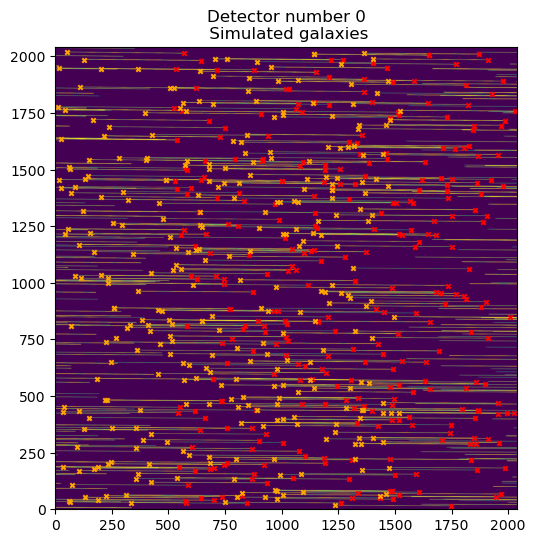

In [49]:
from gelsa import visu

fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(visu.normalize_image(image, levels=(5, 95)), origin='lower')

ax.scatter(x1, y1, c='red', s=10, marker='x', label=r"$\lambda = 12000 \ ang$")
ax.scatter(x2, y2, c='orange', s=10, marker='x', label=r"$\lambda = 19000 \ ang$")

ax.set_title('Detector number {}\n Simulated galaxies'.format(det_num))
ax.set_xlim(0, 2040)
ax.set_ylim(0, 2040)

#### Now we want to compute the average spectra for these simulated sources

We can adapt the *Profile_Fitter* class to do that

In [35]:
m_fit_sim, q_fit_sim, fwhm_sim, avg_spectra_sim = PF.fit_single_detector(det_n=0, smjax_centers=smj_centers, num_per_range=3,
                                                                        image=image, frame=frame_2)


Fitting using provided image data (no loading).
Values in all 3 smjax ranges: set()
Values in exactly 2 smjax ranges: {np.int64(179), np.int64(228), np.int64(133), np.int64(136), np.int64(92)}


100%|██████████| 3/3 [00:02<00:00,  1.23it/s]


In [42]:
fit_line_sim = lambda x: m_fit_sim*x + q_fit_sim

y_val_sim = fit_line_sim(x_val)


Text(0, 0.5, 'FWHM')

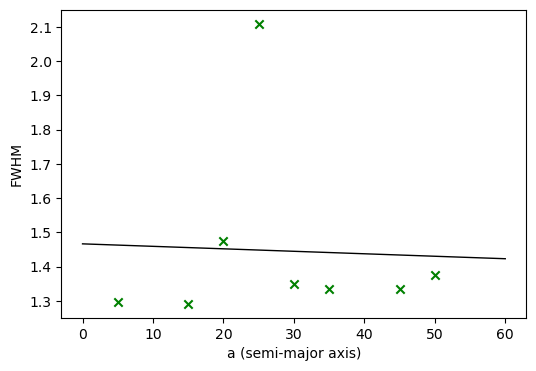

In [43]:
fig = plt.figure(figsize=(6,4))

plt.scatter(smj_centers, fwhm_sim, marker='x', c='green')
plt.plot(x_val, y_val_sim, lw=1, c='k')
plt.xlabel("a (semi-major axis)")
plt.ylabel("FWHM")

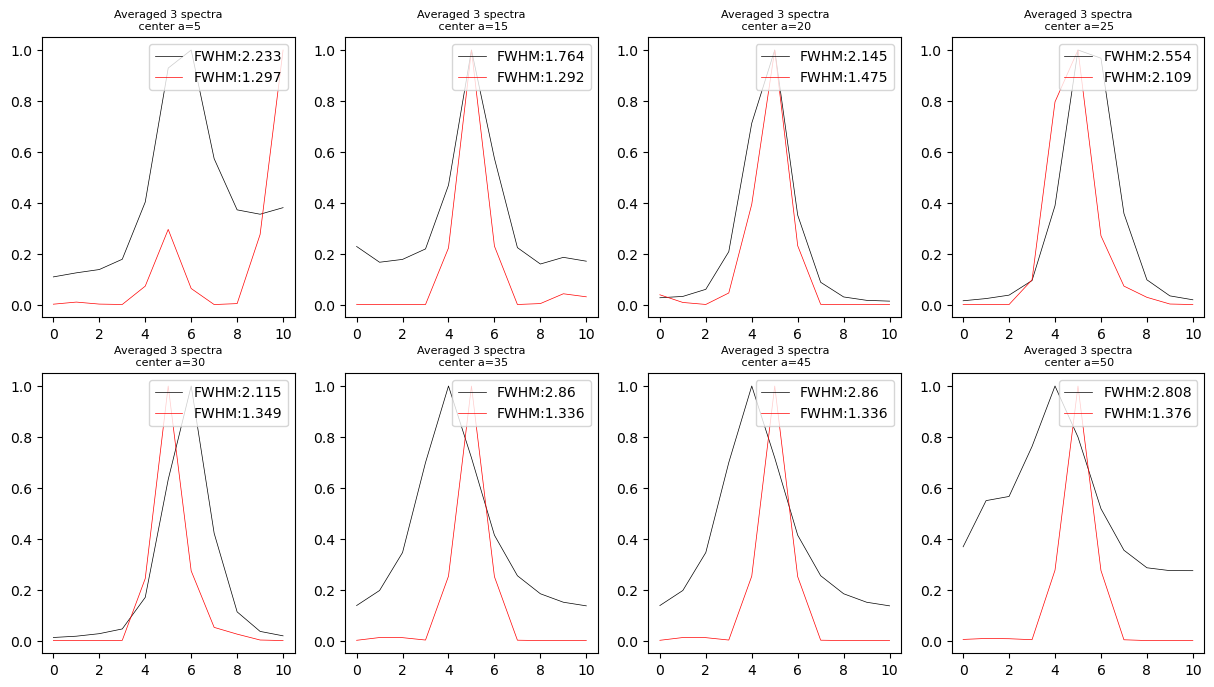

In [47]:
fig, axs = plt.subplots(2, 4, figsize=(15, 8))

for i, ax in enumerate(axs.flat):
    ax.plot(avg_spectra[i]/np.max(avg_spectra[i]), c='k', lw=0.5, label = "FWHM:{}".format(round(fwhm[i], 3)))
    ax.plot(avg_spectra_sim[i]/np.max(avg_spectra_sim[i]), c='red', lw=0.5, label = "FWHM:{}".format(round(fwhm_sim[i], 3)))
    ax.set_title("Averaged 3 spectra\n center a={}".format(smj_centers[i]), fontsize=8)
    ax.legend(loc='upper right')

x1, y1, x2, y2 contain the left-right edges of the objects we have in the frame (detector 0). 
In the frame we have real data, that I'm matching with their properties contained in EDFN_deep.fits catalog

In [15]:
image_real, mask_real, var_real = frame_1.get_detector(0)
im_ma_real = np.ma.array(image_real, mask=mask)


plt.figure(figsize=(7,7))
plt.imshow(visu.normalize_image(im_ma_real, levels=(5, 95)), 
           origin='lower')
for index in range(len(x1)):
    plt.scatter(x1[index], y1[index], s=20, c='r', marker='<')
    plt.scatter(x2[index], y2[index], s=20, c='orange', marker='>')

# for i in range(len(x1)):
    # plt.plot([x1[i], x2[i]], [y1[i], y2[i]], 'r', alpha=0.5)
plt.xlim(0, 2040)
plt.ylim(0, 2040)

NameError: name 'frame' is not defined

In [22]:
ra = cat['RIGHT_ASCENSION'][on_detector][10]
dec = cat['DECLINATION'][on_detector][10]

# im, var, norm, pix_bins = frame.resample_on_wavelength(ra, dec, wave_range=frame.params['wavelength_range'], super_sample=1)